# Walmart Demand-Based Recommendation System — Reviewed Version

This notebook trains a **LightGBM action-scoring recommender**.

For each business situation, the model scores five candidate actions:

- `No_Action`
- `Increase_Inventory`
- `Reduce_Replenishment`
- `Increase_Staffing`
- `Targeted_Promotion`

The action with the highest predicted utility becomes the recommendation.

## Methodological corrections in this reviewed version

1. **The test set is never used for early stopping.**
2. The supplied training period is split chronologically into:
   - development train
   - validation
3. Early stopping selects the best number of boosting iterations using validation only.
4. After model selection, preprocessing is refit on the full supplied training period.
5. A final LightGBM model is retrained on the full supplied training period using the selected number of trees.
6. The test set is evaluated only after the final model is fixed.
7. `Situation_ID` and `Date` are retained for grouping/chronology but excluded from model inputs.
8. Simulator-only and target-derived leakage columns are explicitly checked.
9. The preprocessing pipeline is fit only on training data, never on validation/test data.
10. Recommendation quality is evaluated with ranking metrics, not regression metrics alone.

## Important limitation

The target `Simulated_Utility` is synthetic. This is a proof-of-concept decision-support system, not evidence that an action causally improves real Walmart outcomes.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Load the supplied time-based train and test files

The files were already split chronologically before this notebook. We preserve that split.


In [3]:
TRAIN_PATH = '/content/drive/MyDrive/Depi/Rec_Sys/RECOMMENDATION_TRAIN.csv'
TEST_PATH = '/content/drive/MyDrive/Depi/Rec_Sys/RECOMMENDATION_TEST.csv'

train_df = pd.read_csv(TRAIN_PATH, parse_dates=['Date'])
test_df = pd.read_csv(TEST_PATH, parse_dates=['Date'])

print('Supplied train shape:', train_df.shape)
print('Supplied test shape :', test_df.shape)
print('Train date range:', train_df['Date'].min(), '->', train_df['Date'].max())
print('Test date range :', test_df['Date'].min(), '->', test_df['Date'].max())


Supplied train shape: (79490, 36)
Supplied test shape : (20525, 36)
Train date range: 2010-02-12 00:00:00 -> 2012-03-30 00:00:00
Test date range : 2012-04-06 00:00:00 -> 2012-10-19 00:00:00


## 2. Validate chronology and situation separation

Because every situation has five action rows, splitting individual rows would be dangerous. All five actions belonging to one Situation_ID must stay in the same partition.


In [4]:
train_ids = set(train_df['Situation_ID'].unique())
test_ids = set(test_df['Situation_ID'].unique())
overlap = train_ids.intersection(test_ids)

print('Situation overlap:', len(overlap))
assert len(overlap) == 0, 'Leakage: situations overlap between train and test.'

print('Latest train date:', train_df['Date'].max())
print('Earliest test date:', test_df['Date'].min())

assert train_df['Date'].max() < test_df['Date'].min(), (
    'Expected a strictly chronological supplied train/test split.'
)


Situation overlap: 0
Latest train date: 2012-03-30 00:00:00
Earliest test date: 2012-04-06 00:00:00


## 3. Explicit leakage audit

The model-ready CSV files should not contain future information or simulator outputs other than the target itself.

Simulated_Utility is retained because it is the regression target.


In [5]:
TARGET = 'Simulated_Utility'
GROUP_COL = 'Situation_ID'

FORBIDDEN_FEATURES = [
    'Next_Week_Sales',
    'Demand_Change_Pct',
    'Simulated_Outcome',
    'Action_Cost',
    'Cost_Saving',
    'Action_Rank',
    'Is_Best_Action'
]

present_forbidden = [c for c in FORBIDDEN_FEATURES if c in train_df.columns]
print('Forbidden columns present:', present_forbidden)
assert len(present_forbidden) == 0, (
    'Stop: leakage/simulator-derived columns are present.'
)

assert TARGET in train_df.columns
assert TARGET in test_df.columns


Forbidden columns present: []


## 4. Missing-value inspection

LightGBM can handle missing numeric values. Categorical missing values will be represented explicitly before one-hot encoding.


In [6]:
missing = train_df.isna().sum().sort_values(ascending=False).to_frame('Missing_Count')
missing['Missing_Percent'] = 100 * missing['Missing_Count'] / len(train_df)
display(missing[missing['Missing_Count'] > 0])


,Missing_Count,Missing_Percent
Sales_Lag_3,1480,1.8619
Sales_Lag_2,745,0.9372


## 5. Create a chronological validation period from the supplied training data

The external test set untouched. We take the latest 20% of unique situation dates inside the supplied training period as validation.

Using unique dates avoids cutting the same calendar date across development train and validation.


In [7]:
unique_train_dates = np.sort(train_df['Date'].dropna().unique())

val_start_idx = int(len(unique_train_dates) * 0.80)
val_start_date = pd.Timestamp(unique_train_dates[val_start_idx])

dev_train_df = train_df[train_df['Date'] < val_start_date].copy()
val_df = train_df[train_df['Date'] >= val_start_date].copy()

print('Development train:', dev_train_df.shape)
print('Validation       :', val_df.shape)
print('Validation starts:', val_start_date.date())

print('\nDevelopment date range:',
      dev_train_df['Date'].min(), '->', dev_train_df['Date'].max())
print('Validation date range:',
      val_df['Date'].min(), '->', val_df['Date'].max())

dev_ids = set(dev_train_df['Situation_ID'].unique())
val_ids = set(val_df['Situation_ID'].unique())

assert len(dev_ids.intersection(val_ids)) == 0
assert dev_train_df['Date'].max() < val_df['Date'].min()


Development train: (63055, 36)
Validation       : (16435, 36)
Validation starts: 2011-10-28

Development date range: 2010-02-12 00:00:00 -> 2011-10-21 00:00:00
Validation date range: 2011-10-28 00:00:00 -> 2012-03-30 00:00:00


## 6. Define model features

Excluded from model inputs:

- Simulated_Utility: target
- Situation_ID: arbitrary grouping identifier
- Date: used for chronology; calendar components already exist

Candidate_Action must remain a feature because the model is learning to score different actions.


In [8]:
NON_FEATURE_COLUMNS = [
    TARGET,
    GROUP_COL,
    'Date'
]

feature_columns = [
    c for c in train_df.columns
    if c not in NON_FEATURE_COLUMNS
]

categorical_features = [
    c for c in ['Store', 'Dept', 'Candidate_Action']
    if c in feature_columns
]

numeric_features = [
    c for c in feature_columns
    if c not in categorical_features
]

print('Feature count:', len(feature_columns))
print('Categorical:', categorical_features)
print('Numeric count:', len(numeric_features))


Feature count: 33
Categorical: ['Store', 'Dept', 'Candidate_Action']
Numeric count: 30


## 7. Helper functions for safe preprocessing

fit_transform()`on training data
transform() only on validation/test data

In [9]:
def prepare_raw_X(frame, feature_columns, categorical_features):
    X = frame[feature_columns].copy()

    for col in categorical_features:
        X[col] = X[col].astype('string').fillna('Missing')

    return X

def build_preprocessor(categorical_features, numeric_features):
    return ColumnTransformer(
        transformers=[
            (
                'cat',
                OneHotEncoder(
                    handle_unknown='ignore',
                    sparse_output=True
                ),
                categorical_features
            ),
            (
                'num',
                'passthrough',
                numeric_features
            )
        ],
        remainder='drop',
        sparse_threshold=1.0
    )

## 8. Stage A model selection with development train and validation

We use validation only to determine the best number of boosting iterations.

In [10]:
X_dev_raw = prepare_raw_X(
    dev_train_df, feature_columns, categorical_features
)
X_val_raw = prepare_raw_X(
    val_df, feature_columns, categorical_features
)

y_dev = dev_train_df[TARGET].copy()
y_val = val_df[TARGET].copy()

selection_preprocessor = build_preprocessor(
    categorical_features,
    numeric_features
)

X_dev = selection_preprocessor.fit_transform(X_dev_raw)
X_val = selection_preprocessor.transform(X_val_raw)

print('Processed development shape:', X_dev.shape)
print('Processed validation shape :', X_val.shape)


Processed development shape: (63055, 114)
Processed validation shape : (16435, 114)


In [11]:
selection_model = LGBMRegressor(
    objective='regression',
    n_estimators=2000,       # high ceiling; early stopping chooses the useful amount
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

selection_model.fit(
    X_dev,
    y_dev,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[
        early_stopping(
            stopping_rounds=75,
            verbose=True
        ),
        log_evaluation(period=50)
    ]
)

best_iteration = selection_model.best_iteration_
print('\nSelected boosting iterations:', best_iteration)


Training until validation scores don't improve for 75 rounds
[50]	valid_0's l1: 6704.43	valid_0's l2: 1.41608e+08
[100]	valid_0's l1: 3997.71	valid_0's l2: 8.04435e+07
[150]	valid_0's l1: 3608.72	valid_0's l2: 6.96802e+07
[200]	valid_0's l1: 3511.4	valid_0's l2: 6.65912e+07
[250]	valid_0's l1: 3478.27	valid_0's l2: 6.5145e+07
[300]	valid_0's l1: 3457.94	valid_0's l2: 6.4529e+07
[350]	valid_0's l1: 3440.97	valid_0's l2: 6.3979e+07
[400]	valid_0's l1: 3421.47	valid_0's l2: 6.34276e+07
[450]	valid_0's l1: 3434.36	valid_0's l2: 6.34866e+07
Early stopping, best iteration is:
[421]	valid_0's l1: 3418.37	valid_0's l2: 6.33134e+07

Selected boosting iterations: 421


### Why this is methodologically cleaner

early_stopping watches validation MAE. If validation MAE fails to improve for 75 consecutive boosting rounds, training stops.

log_evaluation(period=50) only prints progress every 50 rounds; it does not change learning.

The selected best_iteration is now a model-design choice learned without touching the external test set.


In [12]:
# Optional validation diagnostics
val_pred = selection_model.predict(
    X_val,
    num_iteration=best_iteration
)

val_mae = mean_absolute_error(y_val, val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
val_r2 = r2_score(y_val, val_pred)

display(pd.DataFrame({
    'Validation_Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [val_mae, val_rmse, val_r2]
}))


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Validation_Metric,Value
0,MAE,"3,418.3691"
1,RMSE,"7,956.9702"
2,R2,0.9412


## 9. Stage B refit preprocessing on the full supplied training period

After selecting the number of trees, we use all available pre-test training data.

This does not leak test information because the test set remains untouched.


In [13]:
X_train_raw = prepare_raw_X(
    train_df, feature_columns, categorical_features
)
X_test_raw = prepare_raw_X(
    test_df, feature_columns, categorical_features
)

y_train = train_df[TARGET].copy()
y_test = test_df[TARGET].copy()

final_preprocessor = build_preprocessor(
    categorical_features,
    numeric_features
)

X_train = final_preprocessor.fit_transform(X_train_raw)
X_test = final_preprocessor.transform(X_test_raw)

final_feature_names = final_preprocessor.get_feature_names_out()

print('Final processed train shape:', X_train.shape)
print('Final processed test shape :', X_test.shape)


Final processed train shape: (79490, 114)
Final processed test shape : (20525, 114)


## 10. Train the final LightGBM model

The final model is trained on the full training with exactly the number of trees selected in Stage A.


In [14]:
final_model = LGBMRegressor(
    objective='regression',
    n_estimators=best_iteration,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

final_model.fit(X_train, y_train)

print('Final model trained with', best_iteration, 'boosting iterations.')


Final model trained with 421 boosting iterations.


## 11. One-time final test evaluation

Now we evaluate the untouched external test set.


In [15]:
y_pred = final_model.predict(X_test)

test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)

test_metrics = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R2'],
    'Value': [test_mae, test_rmse, test_r2]
})

display(test_metrics)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Metric,Value
0,MAE,"2,040.8689"
1,RMSE,"3,581.0219"
2,R2,0.9863


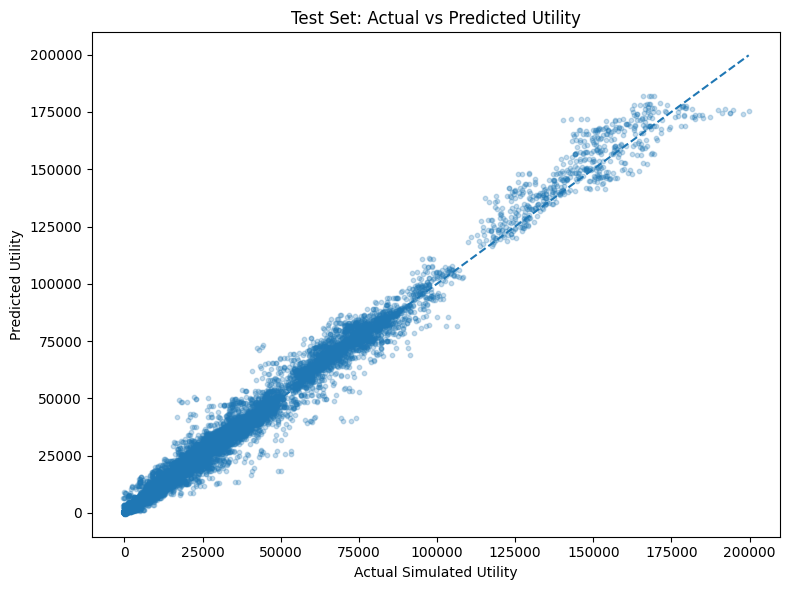

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.25, s=10)

low = min(y_test.min(), y_pred.min())
high = max(y_test.max(), y_pred.max())
plt.plot([low, high], [low, high], linestyle='--')

plt.xlabel('Actual Simulated Utility')
plt.ylabel('Predicted Utility')
plt.title('Test Set: Actual vs Predicted Utility')
plt.tight_layout()
plt.show()


## 12. Build action scores and ranks

Regression metrics alone do not tell us whether the recommender chooses the right action.

For each Situation_ID, we rank all candidate actions by predicted.


In [17]:
results = test_df[
    ['Situation_ID', 'Date', 'Store', 'Dept', 'Candidate_Action', TARGET]
].copy()

results['Predicted_Utility'] = y_pred

results['Predicted_Rank'] = (
    results.groupby('Situation_ID')['Predicted_Utility']
    .rank(method='first', ascending=False)
    .astype(int)
)

results['Actual_Rank'] = (
    results.groupby('Situation_ID')[TARGET]
    .rank(method='first', ascending=False)
    .astype(int)
)

display(results.head(10))


,Situation_ID,Date,Store,Dept,Candidate_Action,Simulated_Utility,Predicted_Utility,Predicted_Rank,Actual_Rank
0,113,2012-04-06,1,1,No_Action,"34,383.2045","49,286.3345",3,4
1,114,2012-04-13,1,1,No_Action,"16,673.6848","30,558.5769",4,2
2,115,2012-04-20,1,1,No_Action,"16,230.9352","20,943.6671",2,2
3,116,2012-04-27,1,1,No_Action,"16,960.0816","23,018.9649",2,2
4,117,2012-05-04,1,1,No_Action,"18,090.2789","19,252.6334",2,2
5,118,2012-05-11,1,1,No_Action,"18,413.7472","20,978.2523",2,2
6,119,2012-05-18,1,1,No_Action,"17,044.4415","21,665.6052",2,2
7,120,2012-05-25,1,1,No_Action,"15,918.2872","18,340.4020",2,2
8,121,2012-06-01,1,1,No_Action,"17,432.2027","21,311.3839",2,2
9,122,2012-06-08,1,1,No_Action,"17,549.1456","19,370.3684",2,2


## 13. Recommendation-specific evaluation

We calculate:

- **Top-1 Action Accuracy**: recommended action equals simulator-best action
- **Top-2 Hit Rate**: simulator-best action appears in the top two predictions
- **Mean Utility Regret**: best available utility minus utility of selected action
- **Median Utility Regret**

Lower regret is better.


In [18]:
predicted_best = (
    results.loc[results['Predicted_Rank'] == 1]
    .sort_values('Situation_ID')
    .copy()
)

actual_best = (
    results.loc[results['Actual_Rank'] == 1]
    [['Situation_ID', 'Candidate_Action', TARGET]]
    .rename(columns={
        'Candidate_Action': 'Actual_Best_Action',
        TARGET: 'Best_Available_Utility'
    })
)

evaluation = predicted_best.merge(
    actual_best,
    on='Situation_ID',
    how='left'
)

evaluation['Top1_Correct'] = (
    evaluation['Candidate_Action']
    == evaluation['Actual_Best_Action']
)

# The selected row's true synthetic utility is TARGET.
evaluation['Utility_Regret'] = (
    evaluation['Best_Available_Utility']
    - evaluation[TARGET]
)

top1_accuracy = evaluation['Top1_Correct'].mean()
mean_regret = evaluation['Utility_Regret'].mean()
median_regret = evaluation['Utility_Regret'].median()

top2 = results[results['Predicted_Rank'] <= 2].merge(
    actual_best[['Situation_ID', 'Actual_Best_Action']],
    on='Situation_ID',
    how='left'
)

top2_hit_rate = (
    top2.assign(
        Hit=top2['Candidate_Action'] == top2['Actual_Best_Action']
    )
    .groupby('Situation_ID')['Hit']
    .any()
    .mean()
)

ranking_metrics = pd.DataFrame({
    'Metric': [
        'Top-1 Action Accuracy',
        'Top-2 Hit Rate',
        'Mean Utility Regret',
        'Median Utility Regret'
    ],
    'Value': [
        top1_accuracy,
        top2_hit_rate,
        mean_regret,
        median_regret
    ]
})

display(ranking_metrics)


,Metric,Value
0,Top-1 Action Accuracy,0.5747
1,Top-2 Hit Rate,0.7559
2,Mean Utility Regret,284.8631
3,Median Utility Regret,0.0000


## 14. Compare actual-best vs recommended actions


In [19]:
action_confusion_counts = pd.crosstab(
    evaluation['Actual_Best_Action'],
    evaluation['Candidate_Action']
)

action_confusion_normalized = pd.crosstab(
    evaluation['Actual_Best_Action'],
    evaluation['Candidate_Action'],
    normalize='index'
)

print('Counts:')
display(action_confusion_counts)

print('Row-normalized proportions:')
display(action_confusion_normalized.round(3))


Counts:


Candidate_Action,Increase_Inventory,Increase_Staffing,No_Action,Reduce_Replenishment,Targeted_Promotion
Actual_Best_Action,,,,,
Increase_Inventory,575,8,8,361,1
Increase_Staffing,62,6,2,126,1
No_Action,168,12,7,660,0
Reduce_Replenishment,321,4,7,1771,2
Targeted_Promotion,0,0,0,3,0


Row-normalized proportions:


Candidate_Action,Increase_Inventory,Increase_Staffing,No_Action,Reduce_Replenishment,Targeted_Promotion
Actual_Best_Action,,,,,
Increase_Inventory,0.6030,0.0080,0.0080,0.3790,0.0010
Increase_Staffing,0.3150,0.0300,0.0100,0.6400,0.0050
No_Action,0.1980,0.0140,0.0080,0.7790,0.0000
Reduce_Replenishment,0.1520,0.0020,0.0030,0.8410,0.0010
Targeted_Promotion,0.0000,0.0000,0.0000,1.0000,0.0000


## 15. Inspect final recommendations


In [20]:
recommendations = (
    results[results['Predicted_Rank'] == 1]
    .rename(columns={
        'Candidate_Action': 'Recommended_Action'
    })
    [[
        'Situation_ID',
        'Date',
        'Store',
        'Dept',
        'Recommended_Action',
        'Predicted_Utility',
        TARGET
    ]]
    .sort_values(['Date', 'Store', 'Dept'])
)

display(recommendations.head(20))


,Situation_ID,Date,Store,Dept,Recommended_Action,Predicted_Utility,Simulated_Utility
4105,113,2012-04-06,1,1,Increase_Inventory,"49,600.8145","37,287.1068"
8239,254,2012-04-06,1,2,Reduce_Replenishment,"48,517.8013","44,499.7615"
8268,395,2012-04-06,1,3,Reduce_Replenishment,"9,271.6869","8,566.9336"
8297,536,2012-04-06,1,4,Reduce_Replenishment,"37,878.6109","37,162.1788"
8326,677,2012-04-06,1,5,Reduce_Replenishment,"26,829.5498","22,274.1230"
8355,818,2012-04-06,1,6,Reduce_Replenishment,"4,590.9556","4,478.9981"
4279,959,2012-04-06,1,7,Increase_Inventory,"25,710.1609","22,399.3190"
8413,1100,2012-04-06,1,8,Reduce_Replenishment,"37,584.7051","36,875.5476"
4337,1241,2012-04-06,1,9,Increase_Inventory,"40,602.4565","32,529.9979"
8471,1382,2012-04-06,1,10,Reduce_Replenishment,"33,924.9069","31,723.3826"


## 16. Inspect all alternatives for one situation

A decision-support interface can show the complete ranking rather than only one action.


In [21]:
sample_situation_id = results['Situation_ID'].iloc[0]

sample_ranking = (
    results[results['Situation_ID'] == sample_situation_id]
    .sort_values('Predicted_Rank')
    [[
        'Situation_ID',
        'Date',
        'Store',
        'Dept',
        'Candidate_Action',
        'Predicted_Utility',
        'Predicted_Rank',
        TARGET,
        'Actual_Rank'
    ]]
)

display(sample_ranking)


,Situation_ID,Date,Store,Dept,Candidate_Action,Predicted_Utility,Predicted_Rank,Simulated_Utility,Actual_Rank
4105,113,2012-04-06,1,1,Increase_Inventory,"49,600.8145",1,"37,287.1068",1
12315,113,2012-04-06,1,1,Increase_Staffing,"49,516.7947",2,"35,531.0277",2
0,113,2012-04-06,1,1,No_Action,"49,286.3345",3,"34,383.2045",4
8210,113,2012-04-06,1,1,Reduce_Replenishment,"48,247.3326",4,"34,469.5733",3
16420,113,2012-04-06,1,1,Targeted_Promotion,"44,440.7027",5,"33,421.4078",5


## 17. Feature importance

LightGBM feature importance indicates how often/usefully features participate in tree splits under the chosen importance definition.


,Feature,Importance
84,num__Weekly_Sales,1479
110,num__Current_Demand_Gap_Pct,1145
99,num__WeekOfYear,1089
111,num__Demand_Volatility,1069
98,num__Day,1052
106,num__Sales_Lag_3,771
104,num__Sales_Lag_1,677
86,num__Temperature,513
108,num__Sales_MA_8,506
105,num__Sales_Lag_2,467


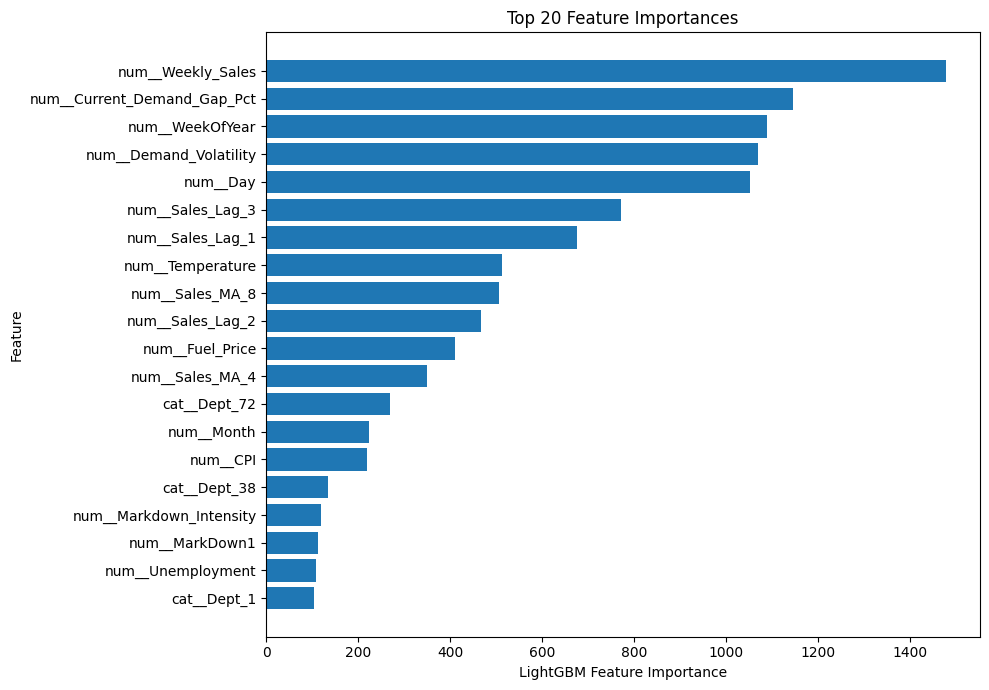

In [22]:
importance_df = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': final_model.feature_importances_
}).sort_values('Importance', ascending=False)

display(importance_df.head(25))

top_imp = importance_df.head(20).sort_values('Importance')

plt.figure(figsize=(10, 7))
plt.barh(top_imp['Feature'], top_imp['Importance'])
plt.xlabel('LightGBM Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()
